In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam


In [31]:
iris=pd.read_csv(r"C:\Users\mishr\Downloads\iris\iris.data")
iris


,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [32]:
iris=pd.read_csv(r"C:\Users\mishr\Downloads\iris\iris.data",header=None)
iris


,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [33]:
iris.columns=['SL','SW','PL','PW','Flowers' ]
iris


,SL,SW,PL,PW,Flowers
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [35]:
iris.Flowers=le.fit_transform(iris.Flowers)
iris.Flowers.unique()


array([0, 1, 2])

In [36]:
le.inverse_transform([0,1,2])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [37]:
ip=iris.drop('Flowers',axis=1)
ip

,SL,SW,PL,PW
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [38]:
op=iris.Flowers
op

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Flowers, Length: 150, dtype: int64

In [39]:
from keras.utils import to_categorical
op=to_categorical(op,3)


In [40]:
op

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    ip,
    op,
    train_size=0.8,
    random_state=3000
)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 

x_test = sc.transform(x_test) 

In [52]:
# Model training 
model = Sequential()
# Input layer 
model.add(Dense(20,input_dim=4,activation="relu"))  
# Hidden layer 
model.add(Dense(35, activation="relu"))              
model.add(Dense(15, activation="relu"))          
#Output Layer    
model.add(Dense(3, activation="softmax"))               
model.compile(Adam(learning_rate=0.01),loss="categorical_crossentropy",metrics=['accuracy'])

In [47]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 35)             │           735 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,423 (5.56 KB)

 Trainable params: 1,423 (5.56 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8167 - loss: 0.7545 - val_accuracy: 0.9000 - val_loss: 0.6055
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8333 - loss: 0.4852 - val_accuracy: 0.9000 - val_loss: 0.3693
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8333 - loss: 0.3413 - val_accuracy: 0.8333 - val_loss: 0.3751
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8583 - loss: 0.2637 - val_accuracy: 0.8333 - val_loss: 0.4265
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8750 - loss: 0.2246 - val_accuracy: 0.9000 - val_loss: 0.2901
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9417 - loss: 0.1665 - val_accuracy: 0.8667 - val_loss: 0.4838
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9750 - loss: 0.1342 - val_accuracy: 0.8667 - val_loss: 0.3817
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9833 - loss: 0.1053 - val_accuracy: 0.8667 - val_loss: 0.3588


In [67]:
y_pred = model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[1.6975520e-05, 9.9994445e-01, 3.8617669e-05],
       [1.0000000e+00, 3.6899479e-08, 2.7847813e-09],
       [2.1075946e-03, 9.9788898e-01, 3.4560869e-06],
       [1.4841500e-04, 9.9984574e-01, 5.7787183e-06],
       [9.9999988e-01, 1.4597519e-07, 1.1700053e-09],
       [1.7291915e-10, 5.6982053e-06, 9.9999428e-01],
       [9.9999881e-01, 1.1843373e-06, 1.7154718e-09],
       [9.9999964e-01, 3.8956972e-07, 2.8748448e-09],
       [2.2665823e-05, 9.9997723e-01, 1.2825866e-07],
       [1.0068948e-08, 5.2144937e-04, 9.9947852e-01],
       [1.2026335e-07, 9.9618536e-01, 3.8144572e-03],
       [9.1929915e-06, 9.9998248e-01, 8.3395735e-06],
       [1.0000000e+00, 3.7579419e-08, 1.1798816e-09],
       [6.8181599e-08, 9.9999988e-01, 8.9081936e-08],
       [2.4893250e-08, 3.1863959e-04, 9.9968135e-01],
       [2.5091083e-08, 7.1103044e-04, 9.9928892e-01],
       [9.4026485e-03, 9.8267007e-01, 7.9273293e-03],
       [5.3453824e-04, 9.9945980e-01, 5.6271674e-06],
       [3.6394139e-04, 9.996

In [68]:
y_pred_class = np.argmax(y_pred, axis=1)
print(y_pred_class)

[1 0 1 1 0 2 0 0 1 2 1 1 0 1 2 2 1 1 1 0 0 1 0 2 1 1 2 1 0 0]


In [71]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(y_test, y_pred)
rc = recall_score(y_test, y_pred, average='micro')
pr = precision_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')

print("Accuracy =", ac)
print("Recall =", rc)
print("Precision =", pr)
print("F1 Score =", f1)

ValueError: Classification metrics can't handle a mix of multilabel-indicator and continuous-multioutput targets

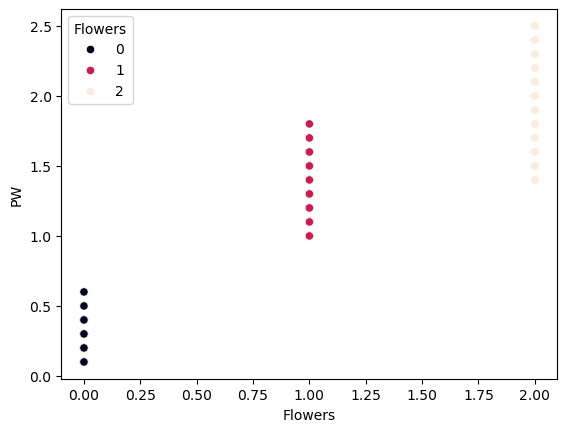

In [65]:
sns.scatterplot(x=iris.Flowers,
                y=iris.PW,
                hue=iris.Flowers, 
                palette='rocket')
plt.show()